# GBM Toolbox vs. VBA Toolbox — observation-only models

This notebook simulates data from **three models** that differ only in their
outcome distribution, fits each with **both toolboxes**, and compares the
parameter estimates.

| model | outcome | link | parameters |
|---|---|---|---|
| continuous | Gaussian | identity | intercept, slope, noise SD |
| binary | Bernoulli | logistic | intercept, slope |
| categorical (3 classes) | Categorical | softmax | a1, b1, a2, b2 |

All three are **observation-only**: there is no hidden state dynamic and no
evolution parameter. Each outcome depends only on a trial-wise regressor `s`
through a linear predictor. This "null evolution" setting is the simplest
place to compare the two toolboxes, because any difference in the estimates
comes from the inference scheme alone, not from state filtering.

**What differs between the toolboxes**

|  | GBM Toolbox | VBA Toolbox |
|---|---|---|
| inference | MAP + Laplace (multi-start L-BFGS-B, autodiff Hessian) | Variational Laplace (Gauss-Newton) |
| evidence | Laplace log-evidence | variational free energy `F` |
| null evolution | omit `evolution`, the evolution prior and `initial_state` | `f_fname = []`, `dim.n = 0` |
| observation fn returns | **logits** (toolbox applies the link) | **probabilities** (you apply the link) |
| categorical `y` coding | integer labels `0..K-1` | one-hot, `K x T` |
| Gaussian noise | `Ga(1,1)` on precision, fitted as `log_observation_sd` | `Ga(1,1)` on the precision |

Those last three rows are the easy ones to get wrong, so they are pointed out
again at each model below.

Note on the noise prior: both toolboxes now default to the same `Ga(1, 1)`
prior on observation precision, so the continuous model is compared on equal
terms. It assumes an observation SD of order 1, which is fine here because the
simulated outcomes are already O(1). For data on a very different scale -- and
especially with few trials -- state the scale instead with
`observation_noise_prior_from_scale(y)`.

## 1. Setup

In [1]:
import subprocess
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

from gbmtoolbox import Config, GaussianPrior, Priors, StateModel, individual_fit
from simulate import simulate_all, one_hot

# --- paths: edit these two if your install lives elsewhere -----------------
MATLAB = "/Users/gino.diez/Applications/Matlab_R2025b.app/bin/matlab"
VBA_PATH = "/Users/gino.diez/Documents/MATLAB/VBA-toolbox-master"

HERE = Path.cwd()
DATA_MAT = HERE / "sim_data.mat"
VBA_MAT = HERE / "vba_fits.mat"

# --- simulation settings ---------------------------------------------------
N_SUBJECTS = 20
N_TRIALS = 200
SEED = 1

# More trials -> both toolboxes converge to the same answer and to the truth.
# Fewer trials -> priors matter more, and the two schemes can differ slightly.
print(f"{N_SUBJECTS} subjects x {N_TRIALS} trials")

20 subjects x 200 trials


## 2. Simulate the three datasets

The generative equations are in `simulate.py`. Each subject gets their own
parameters drawn from a uniform range, so the scatter plots later have
something to correlate.

In [2]:
datasets = simulate_all(seed=SEED, n_subjects=N_SUBJECTS, n_trials=N_TRIALS)

(cont_data, true_cont) = datasets["continuous"]
(bin_data, true_bin) = datasets["binary"]
(cat_data, true_cat) = datasets["categorical"]

print("continuous y:", cont_data["y"].shape, "  e.g.", np.round(cont_data["y"][0, :4], 2))
print("binary      y:", bin_data["y"].shape, "  e.g.", bin_data["y"][0, :8])
print("categorical y:", cat_data["y"].shape, "  e.g.", cat_data["y"][0, :8], "(labels 0..2)")

continuous y: (20, 200)   e.g. [-0.69  0.39  0.64 -1.05]
binary      y: (20, 200)   e.g. [0 1 1 0 0 0 0 0]
categorical y: (20, 200)   e.g. [2 0 1 0 2 2 2 1] (labels 0..2)


### Save the data for MATLAB

The same arrays go to both toolboxes. The only transformation is the
categorical outcome, which VBA needs **one-hot coded as `K x T`** while GBM
Toolbox takes the integer labels directly.

In [3]:
sio.savemat(DATA_MAT, {
    "n_subjects": N_SUBJECTS,
    "cont_y": cont_data["y"], "cont_u": cont_data["u"],
    "bin_y": bin_data["y"].astype(float), "bin_u": bin_data["u"],
    "cat_y": one_hot(cat_data["y"]),  # (n_subjects, 3, T) one-hot for VBA
    "cat_u": cat_data["u"],
})
print("wrote", DATA_MAT)

wrote /Users/gino.diez/Documents/gbm/comparison_vba/sim_data.mat


## 3. Fit with GBM Toolbox

### Observation-only models

These models have no latent dynamics, so we simply **omit** the `evolution`
function and the evolution prior. `theta` is then an empty vector and only the
observation parameters are estimated.

`initial_state` is omitted too: it defaults to `[0.0]`, and with no evolution
and an observation function that ignores `x`, its value cannot affect the fit.

In [4]:
def make_model(family, observation, param_names, prior_var, observation_dim=None):
    """Observation-only StateModel: no evolution function, no evolution prior."""
    return StateModel(
        observation=observation,
        family=family,
        priors=Priors(
            observation=GaussianPrior(
                [0.0] * len(param_names),
                [prior_var] * len(param_names),
                names=param_names,
            ),
        ),
        observation_dim=observation_dim,
    )

### The three observation functions

Remember: GBM Toolbox expects the **natural parameter** (the logit / logit
vector), not a probability. The toolbox applies the sigmoid or softmax itself.

In [5]:
def obs_continuous(x, phi, u_t):
    """Gaussian: return the predicted mean."""
    return phi[0] + phi[1] * u_t


def obs_binary(x, phi, u_t):
    """Bernoulli: return the LOGIT, not the probability."""
    return phi[0] + phi[1] * u_t


def obs_categorical(x, phi, u_t):
    """Categorical: return a vector of LOGITS, class 0 fixed to 0 as reference."""
    return jnp.array([0.0, phi[0] + phi[1] * u_t, phi[2] + phi[3] * u_t])


model_cont = make_model("gaussian", obs_continuous, ["intercept", "slope"], 1.0)
model_bin = make_model("bernoulli", obs_binary, ["b0", "b1"], 4.0)
model_cat = make_model("categorical", obs_categorical, ["a1", "b1", "a2", "b2"], 4.0,
                       observation_dim=3)

# The Gaussian model gains a log_observation_sd parameter automatically:
# GBM Toolbox estimates the observation noise by default.
print("continuous  parameters:", model_cont.parameter_layout.names)
print("binary      parameters:", model_bin.parameter_layout.names)
print("categorical parameters:", model_cat.parameter_layout.names)

continuous  parameters: ('intercept', 'slope', 'log_observation_sd')
binary      parameters: ('b0', 'b1')
categorical parameters: ('a1', 'b1', 'a2', 'b2')


In [6]:
def to_subject_list(data):
    """(n_subjects, T) arrays -> the list-of-dicts GBM Toolbox expects."""
    return [{"y": data["y"][i], "u": data["u"][i]} for i in range(data["y"].shape[0])]


cfg = Config(num_init=5, random_state=SEED, display=False)

fit_cont = individual_fit(to_subject_list(cont_data), model_cont, config=cfg)
fit_bin = individual_fit(to_subject_list(bin_data), model_bin, config=cfg)
fit_cat = individual_fit(to_subject_list(cat_data), model_cat, config=cfg)

# Collect the estimates. For the continuous model the noise SD is reported
# separately from the observation parameters.
gbm_cont = np.column_stack([
    fit_cont.output.observation_parameters,
    fit_cont.output.observation_noise_sd[:, 0],
])
gbm_bin = fit_bin.output.observation_parameters
gbm_cat = fit_cat.output.observation_parameters

print(fit_cont.summary(subject=0))

Subject 01: log joint=-222.706, Laplace=valid
Subject 02: log joint=-251.858, Laplace=valid
Subject 03: log joint=-230.169, Laplace=valid


Subject 04: log joint=-125.232, Laplace=valid
Subject 05: log joint=-276.596, Laplace=valid
Subject 06: log joint=-208.703, Laplace=valid


Subject 07: log joint=-197.268, Laplace=valid
Subject 08: log joint=-255.482, Laplace=valid
Subject 09: log joint=-106.275, Laplace=valid


Subject 10: log joint=-233.772, Laplace=valid
Subject 11: log joint=-240.582, Laplace=valid
Subject 12: log joint=-244.428, Laplace=valid


Subject 13: log joint=-109.765, Laplace=valid
Subject 14: log joint=-249.128, Laplace=valid


...

Subject 01: log joint=-145.597, Laplace=valid
Subject 02: log joint=-157.224, Laplace=valid
Subject 03: log joint=-138.109, Laplace=valid
Subject 04: log joint=-141.114, Laplace=valid


Subject 05: log joint=-134.688, Laplace=valid
Subject 06: log joint=-153.645, Laplace=valid
Subject 07: log joint=-129.097, Laplace=valid
Subject 08: log joint=-171.431, Laplace=valid


Subject 09: log joint=-164.554, Laplace=valid
Subject 10: log joint=-179.520, Laplace=valid
Subject 11: log joint=-135.185, Laplace=valid
Subject 12: log joint=-181.633, Laplace=valid


Subject 13: log joint=-143.442, Laplace=valid
Subject 14: log joint=-175.331, Laplace=valid
Subject 15: log joint=-151.371, Laplace=valid
Subject 16: log joint=-194.401, Laplace=valid


Subject 17: log joint=-170.950, Laplace=valid
Subject 18: log joint=-164.448, Laplace=valid
Subject 19: log joint=-147.559, Laplace=valid
Subject 20: log joint=-142.290, Laplace=valid
GBM Toolbox fit · StateModel · subject 0
family=gaussian  loglik=-218.732  log-evidence=-228.803
parameters: intercept=0.07076, slope=1.553, log_observation_sd=-0.3216
observation SD: 0.725
Laplace valid=True  fragile=False  kappa=1.34


## 4. Fit with the VBA Toolbox

`fit_vba.m` loops over subjects and calls `VBA_NLStateSpaceModel` with
`f_fname = []` and `dim.n = 0`, which is how VBA expresses a static
(observation-only) model. The priors are set to match the ones used above.

This shells out to MATLAB in batch mode; it takes a couple of minutes.

In [7]:
cmd = [
    MATLAB, "-batch",
    f"addpath('{HERE}'); fit_vba('{DATA_MAT}', '{VBA_MAT}', '{VBA_PATH}');",
]
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout[-2000:] or proc.stderr[-2000:])

VBA fits written to /Users/gino.diez/Documents/gbm/comparison_vba/vba_fits.mat



In [8]:
V = sio.loadmat(VBA_MAT)

vba_cont = np.column_stack([V["mu_cont"], V["sigma_cont"][:, 0]])
vba_bin = V["mu_bin"]
vba_cat = V["mu_cat"]

print("VBA continuous estimates (first 3 subjects):")
print(np.round(vba_cont[:3], 3))

VBA continuous estimates (first 3 subjects):
[[ 0.071  1.553  0.729]
 [ 0.844  0.911  0.844]
 [-0.687  1.298  0.757]]


## 5. Compare the estimates

Each panel plots one parameter: GBM Toolbox on the x-axis, VBA on the y-axis,
one dot per subject. The dashed line is the identity. The annotation gives the
Pearson correlation `r` across subjects and the mean absolute difference.

In [9]:
def compare(gbm, vba, truth, names, title):
    """Scatter GBM vs VBA per parameter and report r + mean |difference|."""
    n = len(names)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.4))
    axes = np.atleast_1d(axes)
    rows = []
    for j, (ax, name) in enumerate(zip(axes, names)):
        a, b = gbm[:, j], vba[:, j]
        r = np.corrcoef(a, b)[0, 1]
        mad = np.mean(np.abs(a - b))
        ax.scatter(a, b, s=28, alpha=0.8, edgecolor="k", linewidth=0.4)
        lo = min(a.min(), b.min())
        hi = max(a.max(), b.max())
        pad = 0.05 * (hi - lo + 1e-9)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--k", linewidth=1)
        ax.set_title(f"{name}\nr = {r:.4f}   MAD = {mad:.4f}", fontsize=10)
        ax.set_xlabel("GBM Toolbox")
        if j == 0:
            ax.set_ylabel("VBA Toolbox")
        # correlation of each toolbox with the true generating values
        rows.append((name, r, mad,
                     np.corrcoef(a, truth[:, j])[0, 1],
                     np.corrcoef(b, truth[:, j])[0, 1]))
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()

    print(f"{'parameter':<12}{'r(GBM,VBA)':>12}{'MAD':>10}{'r(GBM,true)':>13}{'r(VBA,true)':>13}")
    for name, r, mad, rg, rv in rows:
        print(f"{name:<12}{r:>12.4f}{mad:>10.4f}{rg:>13.4f}{rv:>13.4f}")

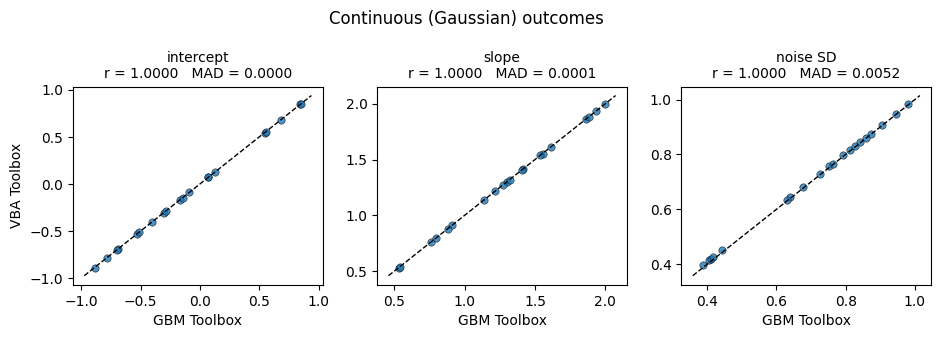

parameter     r(GBM,VBA)       MAD  r(GBM,true)  r(VBA,true)
intercept         1.0000    0.0000       0.9947       0.9947
slope             1.0000    0.0001       0.9936       0.9936
noise SD          1.0000    0.0052       0.9767       0.9764


In [10]:
compare(gbm_cont, vba_cont, true_cont,
        ["intercept", "slope", "noise SD"], "Continuous (Gaussian) outcomes")

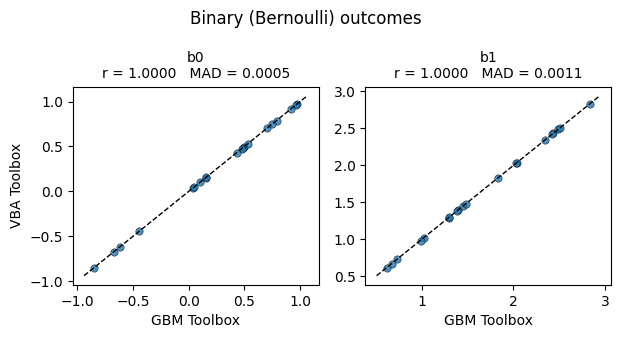

parameter     r(GBM,VBA)       MAD  r(GBM,true)  r(VBA,true)
b0                1.0000    0.0005       0.9505       0.9506
b1                1.0000    0.0011       0.9690       0.9690


In [11]:
compare(gbm_bin, vba_bin, true_bin, ["b0", "b1"], "Binary (Bernoulli) outcomes")

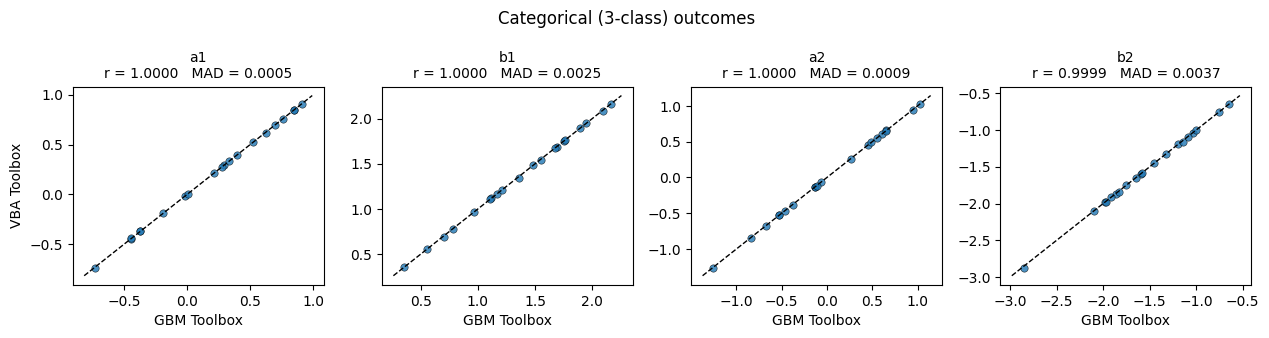

parameter     r(GBM,VBA)       MAD  r(GBM,true)  r(VBA,true)
a1                1.0000    0.0005       0.9410       0.9411
b1                1.0000    0.0025       0.8735       0.8734
a2                1.0000    0.0009       0.8597       0.8595
b2                0.9999    0.0037       0.7847       0.7808


In [12]:
compare(gbm_cat, vba_cat, true_cat,
        ["a1", "b1", "a2", "b2"], "Categorical (3-class) outcomes")

## 6. Fitted probabilities for the discrete models

The observation function returns **logits**, but no information is lost: the
fitted **probabilities** are reported in `fit.output.prediction` for every
trial. For Bernoulli that is `p(y=1)`; for categorical it is the full
probability vector over classes, and each row sums to 1.

This is exactly what VBA's observation function returns directly, so the two
are compared on the same scale here.

binary p(y=1), first 5 trials: [0.264 0.795 0.933 0.617 0.281]
categorical class probabilities, first 3 trials:
[[0.131 0.043 0.826]
 [0.328 0.272 0.4  ]
 [0.278 0.672 0.049]]
row sums: [1. 1. 1.]


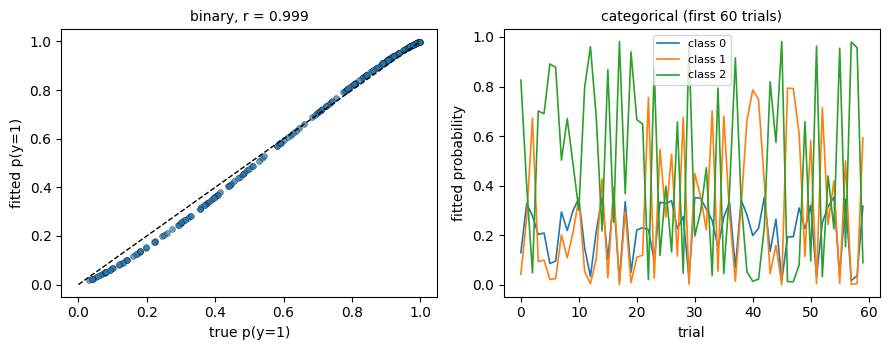

In [13]:
p_gbm = fit_bin.output.prediction[0]          # p(y=1) per trial, subject 0
probs_cat = fit_cat.output.prediction[0]      # (T, 3), rows sum to 1

print("binary p(y=1), first 5 trials:", np.round(p_gbm[:5], 3))
print("categorical class probabilities, first 3 trials:")
print(np.round(probs_cat[:3], 3))
print("row sums:", np.round(probs_cat[:3].sum(axis=1), 6))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

# Recover the true generating probabilities for subject 0 to compare against.
s0 = bin_data["u"][0]
p_true = 1.0 / (1.0 + np.exp(-(true_bin[0, 0] + true_bin[0, 1] * s0)))
axes[0].scatter(p_true, p_gbm, s=18, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].plot([0, 1], [0, 1], "--k", linewidth=1)
axes[0].set_xlabel("true p(y=1)")
axes[0].set_ylabel("fitted p(y=1)")
axes[0].set_title(f"binary, r = {np.corrcoef(p_true, p_gbm)[0, 1]:.3f}", fontsize=10)

for k in range(3):
    axes[1].plot(probs_cat[:60, k], label=f"class {k}", linewidth=1.2)
axes[1].set_xlabel("trial")
axes[1].set_ylabel("fitted probability")
axes[1].set_title("categorical (first 60 trials)", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Parameter recovery

The comparison above only shows that the two toolboxes agree. This section
checks the more important question: do they recover the values that actually
generated the data?

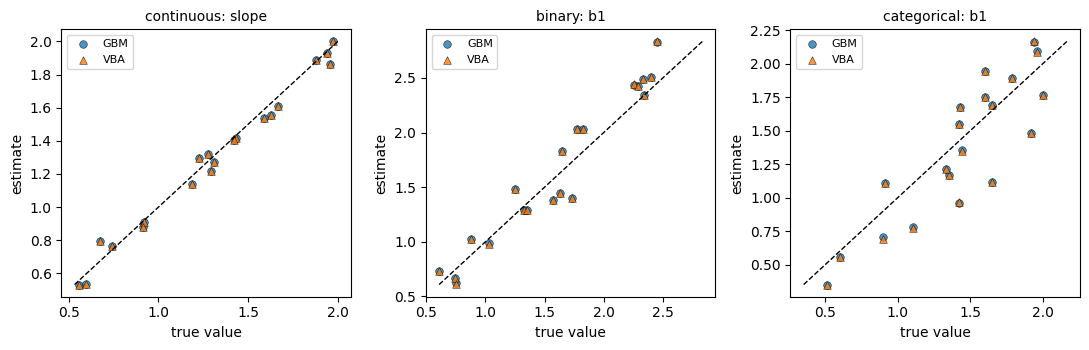

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (truth, gbm, vba, label) in zip(axes, [
    (true_cont[:, 1], gbm_cont[:, 1], vba_cont[:, 1], "continuous: slope"),
    (true_bin[:, 1], gbm_bin[:, 1], vba_bin[:, 1], "binary: b1"),
    (true_cat[:, 1], gbm_cat[:, 1], vba_cat[:, 1], "categorical: b1"),
]):
    ax.scatter(truth, gbm, s=30, alpha=0.8, label="GBM", edgecolor="k", linewidth=0.4)
    ax.scatter(truth, vba, s=30, alpha=0.8, marker="^", label="VBA",
               edgecolor="k", linewidth=0.4)
    lo = min(truth.min(), gbm.min(), vba.min())
    hi = max(truth.max(), gbm.max(), vba.max())
    ax.plot([lo, hi], [lo, hi], "--k", linewidth=1)
    ax.set_xlabel("true value")
    ax.set_ylabel("estimate")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 8. Model evidence

GBM Toolbox reports a **Laplace log-evidence**; VBA reports a **variational
free energy `F`**. Both approximate the same log marginal likelihood, so they
are expected to track each other across subjects, but they are computed
differently and the priors on the noise differ, so the absolute values are not
expected to match.

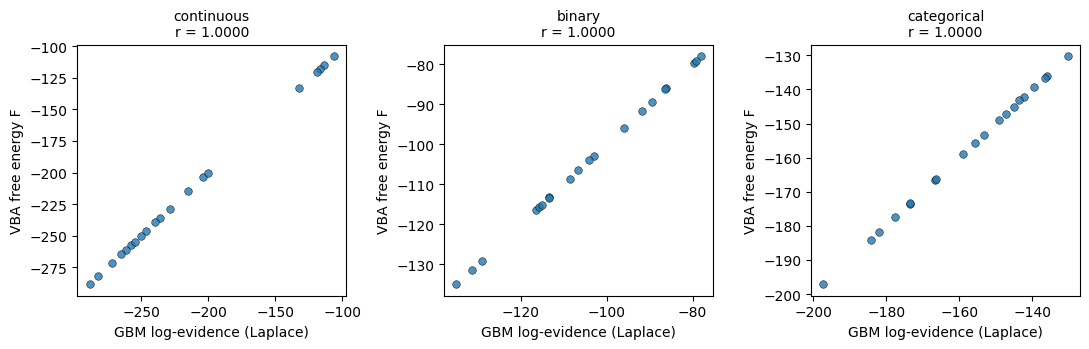

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (gbm_ev, vba_ev, label) in zip(axes, [
    (fit_cont.output.log_evidence, V["F_cont"][:, 0], "continuous"),
    (fit_bin.output.log_evidence, V["F_bin"][:, 0], "binary"),
    (fit_cat.output.log_evidence, V["F_cat"][:, 0], "categorical"),
]):
    r = np.corrcoef(gbm_ev, vba_ev)[0, 1]
    ax.scatter(gbm_ev, vba_ev, s=30, alpha=0.8, edgecolor="k", linewidth=0.4)
    ax.set_xlabel("GBM log-evidence (Laplace)")
    ax.set_ylabel("VBA free energy F")
    ax.set_title(f"{label}\nr = {r:.4f}", fontsize=10)
fig.tight_layout()
plt.show()

## Summary

- The three models are observation-only, so any disagreement is due to the
  inference scheme, not to state filtering.
- The two toolboxes are expressed differently — logits vs probabilities,
  integer vs one-hot categorical outcomes, a fixed dummy parameter vs
  `dim.n = 0` — but describe the same generative model.
- With enough trials the MAP/Laplace and Variational-Laplace estimates agree
  closely; the remaining differences are largest where the likelihood is
  flattest and the prior therefore does most of the work (the noise SD, and
  parameters of rarely-chosen categorical classes).

To re-run with different settings, change `N_SUBJECTS`, `N_TRIALS` or `SEED`
in section 1 and run the notebook top to bottom. Lowering `N_TRIALS` is the
quickest way to see the two schemes come apart.